In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import math
import shutil
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
DATASET_PATH = "/content/drive/MyDrive/AneN_Dasaset"

WORK_DIR = "/content/AneN_Dasaset"

os.makedirs(WORK_DIR, exist_ok=True)

classes = ["Anemic_individuals", "Healthy_individuals"]

In [4]:
SAMPLES_PER_CLASS = 500

files_by_class = {}

for cls in classes:

    cls_dir = pathlib.Path(DATASET_PATH) / cls

    files = [str(p) for p in cls_dir.glob("*") if p.suffix.lower() in [".png",".jpg",".jpeg"]]

    random.shuffle(files)

    files_by_class[cls] = files[:SAMPLES_PER_CLASS]

In [5]:
splits = {
    "train":0.7,
    "val":0.15,
    "test":0.15
}

for split in splits:

    for cls in classes:

        os.makedirs(os.path.join(WORK_DIR,split,cls),exist_ok=True)

In [6]:
for cls in classes:

    files = files_by_class[cls]

    n = len(files)

    n_train = math.floor(n * splits["train"])
    n_val = math.floor(n * splits["val"])

    train_files = files[:n_train]
    val_files = files[n_train:n_train+n_val]
    test_files = files[n_train+n_val:]

    for f in train_files:
        shutil.copy(f, os.path.join(WORK_DIR,"train",cls,os.path.basename(f)))

    for f in val_files:
        shutil.copy(f, os.path.join(WORK_DIR,"val",cls,os.path.basename(f)))

    for f in test_files:
        shutil.copy(f, os.path.join(WORK_DIR,"test",cls,os.path.basename(f)))

print("Dataset Ready:",WORK_DIR)

Dataset Ready: /content/AneN_Dasaset


In [7]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(split):

    ds = tf.keras.utils.image_dataset_from_directory(

        os.path.join(WORK_DIR,split),

        labels="inferred",
        label_mode="binary",

        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,

        shuffle=(split=="train")
    )

    return ds


train_ds = make_ds("train")
val_ds   = make_ds("val")
test_ds  = make_ds("test")

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.


In [8]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)

])

In [9]:
def prepare(ds,training=False):

    ds = ds.map(lambda x,y: (tf.keras.applications.mobilenet_v2.preprocess_input(x),y),
                num_parallel_calls=AUTOTUNE)

    if training:

        ds = ds.map(lambda x,y:(data_augmentation(x,training=True),y),
                    num_parallel_calls=AUTOTUNE)

        ds = ds.shuffle(1000)

    return ds.prefetch(AUTOTUNE)


train_ds = prepare(train_ds,True)
val_ds   = prepare(val_ds,False)
test_ds  = prepare(test_ds,False)

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn():

    inputs = keras.Input(shape=(224,224,3))

    x = layers.Conv2D(32,3,activation="relu",padding="same")(inputs)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(128,3,activation="relu",padding="same")(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(256,3,activation="relu",padding="same")(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128,activation="relu")(x)

    outputs = layers.Dense(1,activation="sigmoid")(x)

    model = keras.Model(inputs,outputs)

    return model


cnn_model = build_cnn()

cnn_model.compile(

    optimizer=keras.optimizers.Adam(1e-3),

    loss="binary_crossentropy",

    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn_history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 515ms/step - accuracy: 0.4871 - auc: 0.4941 - loss: 0.6961 - val_accuracy: 0.5000 - val_auc: 0.4931 - val_loss: 0.6933
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.4896 - auc: 0.5342 - loss: 0.6942 - val_accuracy: 0.4667 - val_auc: 0.5633 - val_loss: 0.6920
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.5481 - auc: 0.6032 - loss: 0.6838 - val_accuracy: 0.6333 - val_auc: 0.5419 - val_loss: 0.6916
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.5909 - auc: 0.6194 - loss: 0.6728 - val_accuracy: 0.5267 - val_auc: 0.5406 - val_loss: 0.6914
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.6069 - auc: 0.6321 - loss: 0.6628 - val_accuracy: 0.5800 - val_auc: 0.5721 - val_loss: 0.6825
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.5514 - auc: 0.5904 - loss: 0.6724 - val_accuracy: 0.4400 - val_auc: 0.5507 - val_loss: 0.7142
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━

In [12]:
base_model = keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
inputs = keras.Input(shape=(224,224,3))

x = base_model(inputs,training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1,activation="sigmoid")(x)

model = keras.Model(inputs,outputs)

In [14]:
model.compile(

optimizer=keras.optimizers.Adam(1e-3),

loss="binary_crossentropy",

metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

In [15]:
callbacks = [

tf.keras.callbacks.EarlyStopping(
patience=5,
restore_best_weights=True,
monitor="val_accuracy"),

tf.keras.callbacks.ReduceLROnPlateau(
patience=3,
factor=0.5)

]

history = model.fit(

train_ds,

validation_data=val_ds,

epochs=20,

callbacks=callbacks
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4674 - auc: 0.4735 - loss: 0.8871 - val_accuracy: 0.6333 - val_auc: 0.6644 - val_loss: 0.6527 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.6287 - auc: 0.6359 - loss: 0.7009 - val_accuracy: 0.6400 - val_auc: 0.7411 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.6489 - auc: 0.6946 - loss: 0.6594 - val_accuracy: 0.6800 - val_auc: 0.7746 - val_loss: 0.5877 - learning_rate: 0.0010
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.6800 - auc: 0.7382 - loss: 0.6176 - val_accuracy: 0.6933 - val_auc: 0.7746 - val_loss: 0.5758 - learning_rate: 0.0010
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.6691 - auc: 0.7391 - loss: 0.6004 - val_accuracy: 0.7133 - val_auc: 0.7867 - val_loss: 0.5579 - learning_rate: 0.0010
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.6684 - auc: 0.

In [16]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(

optimizer=keras.optimizers.Adam(1e-4),

loss="binary_crossentropy",

metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

history_fine = model.fit(

train_ds,

validation_data=val_ds,

epochs=15
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.6036 - auc: 0.6536 - loss: 0.8469 - val_accuracy: 0.6667 - val_auc: 0.7956 - val_loss: 0.6725
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.7288 - auc: 0.8170 - loss: 0.5239 - val_accuracy: 0.6867 - val_auc: 0.8044 - val_loss: 0.6706
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.7608 - auc: 0.8361 - loss: 0.4965 - val_accuracy: 0.6533 - val_auc: 0.7744 - val_loss: 0.8530
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.7196 - auc: 0.8159 - loss: 0.5386 - val_accuracy: 0.5533 - val_auc: 0.7605 - val_loss: 1.1960
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.7708 - auc: 0.8583 - loss: 0.4677 - val_accuracy: 0.5667 - val_auc: 0.7288 - val_loss: 1.3068
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.8106 - auc: 0.8957 - loss: 0.4054 - val_accuracy: 0.5800 - val_auc: 0.7319 - val_loss: 1.2914
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
test_metrics = model.evaluate(test_ds)

print("Test Results:",dict(zip(model.metrics_names,test_metrics)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.7109 - auc: 0.5170 - loss: 0.5548
Test Results: {'loss': 0.6410655379295349, 'compile_metrics': 0.6600000262260437}


In [18]:
y_true = np.concatenate([y for x,y in test_ds],axis=0)

y_pred = np.concatenate([model.predict(x).ravel() for x,_ in test_ds],axis=0)

y_hat = (y_pred >= 0.5).astype(int)

accuracy = (y_hat == y_true).mean()

print("Final Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Final Accuracy: 0.5


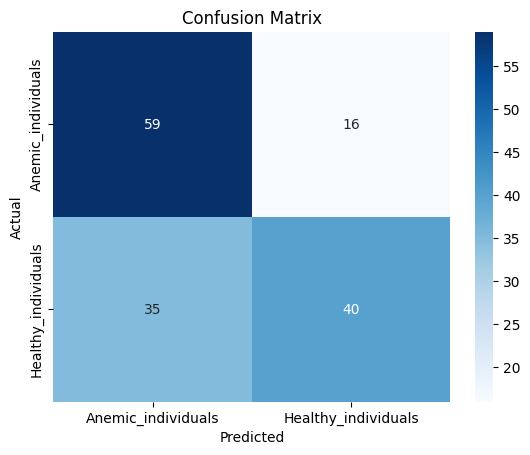

                     precision    recall  f1-score   support

 Anemic_individuals       0.63      0.79      0.70        75
Healthy_individuals       0.71      0.53      0.61        75

           accuracy                           0.66       150
          macro avg       0.67      0.66      0.65       150
       weighted avg       0.67      0.66      0.65       150



In [19]:
from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(y_true,y_hat)

sns.heatmap(cm,annot=True,fmt='d',cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_true,y_hat,target_names=classes))

<Figure size 640x480 with 0 Axes>

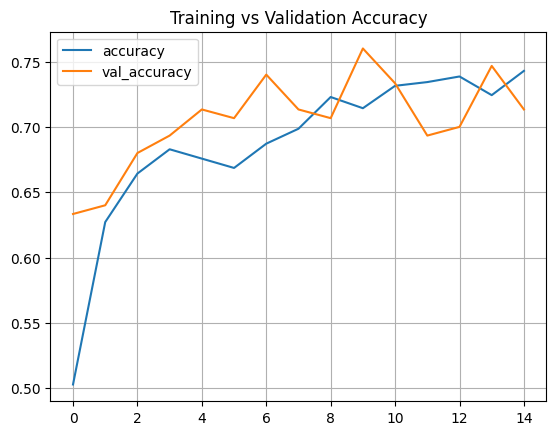

<Figure size 640x480 with 0 Axes>

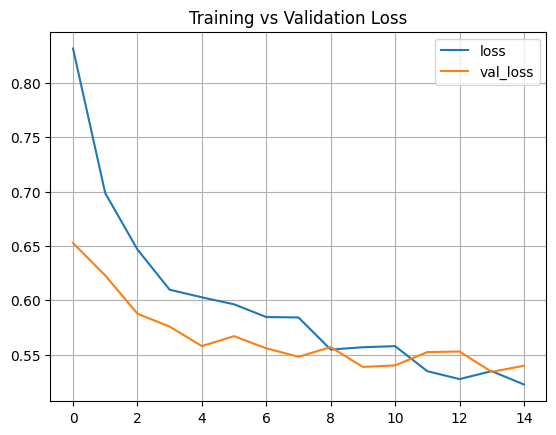

In [20]:
history_df = pd.DataFrame(history.history)

plt.figure()
history_df[['accuracy','val_accuracy']].plot()
plt.title("Training vs Validation Accuracy")
plt.grid(True)
plt.show()

plt.figure()
history_df[['loss','val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.show()

In [23]:
model.save("/content/drive/MyDrive/New folder/anemia_detection_model.keras")

print("Model Saved to Google Drive Successfully")

Model Saved to Google Drive Successfully
